# Spacing and $t$-Spacing Tests for Spiked Tensor PCA

This notebook presents the numerical experiments of the paper:

> **Second maximum of a Gaussian random field and exact ($t$-)spacing test**  
> *Jean-Marc Azaïs, Federico Dalmao, and Yohann De Castro*

---

## Mathematical setup

We consider a Gaussian random field $Z(\cdot)$ defined on a $\mathcal{C}^2$ compact Riemannian manifold $M$ of dimension $d$ without boundary:
$$
\forall t \in M, \quad Z(t) = m(t) + \sigma X(t),
$$
where $m(\cdot)$ is a $\mathcal{C}^2$-function, $\sigma > 0$ is the standard deviation, and $X(\cdot)$ is a centered unit-variance Gaussian random field.

We test the null hypothesis $\mathbb{H}_0: m(\cdot) = 0$ using the **spacing test** and the **$t$-spacing test**, which are based on the first and second maxima $\lambda_1$ and $\lambda_2$, and the residual part of the Riemannian Hessian $\Omega$.

### The spacing test $p$-value

When $\sigma$ is known, the $p$-value $\hat\alpha$ is given by:
$$
\hat\alpha = \frac{\displaystyle\int_{\lambda_1/\sigma}^{+\infty} \det(u\,\mathrm{Id} - \Omega/\sigma)\,\varphi(u)\,\mathrm{d}u}{\displaystyle\int_{\lambda_2/\sigma}^{+\infty} \det(u\,\mathrm{Id} - \Omega/\sigma)\,\varphi(u)\,\mathrm{d}u},
$$
where $\varphi$ is the standard Gaussian density. Under $\mathbb{H}_0$, $\hat \alpha \sim \mathrm{Uniform}(0,1)$.

### The $t$-spacing test

When $\sigma$ is unknown, we replace $\sigma$ by an estimate $\hat\sigma$ built from the Karhunen–Loève expansion of $X^{|t_1}(\cdot)$, yielding the **$t$-spacing test**.

### Application: Spiked tensor PCA

In the experiments below, we consider the detection of a rank-one $3$-way symmetric tensor on the sphere $M = \mathbb{S}^2$ ($d=2$). The Euclidean space of $3$-way symmetric tensors of size $3\times 3\times 3$ has dimension $m=10$. The feature map is $\psi_t = t^{\otimes 3}$ and the Gaussian random field is $X(t) = \langle W, \psi_t \rangle_E$, where $W$ is a random symmetric tensor.

The alternative hypothesis is:
$$
\mathbb{H}_1(t_0, \lambda_0): \quad m(\cdot) = \lambda_0\, c(\cdot, t_0), \qquad \lambda_0 = \gamma \sqrt{3 \log 3 + 3 \log\log 3},
$$
where $\gamma = 0$ corresponds to the null, and $\gamma = 1$ is the phase transition threshold.

---
## 1. Imports and configuration

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi, norm
from pathlib import Path

# Plot defaults
sns.set_theme(context="paper", style="darkgrid")
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300})

---
## 2. Load Monte-Carlo experiment data

We load all CSV files starting with `C_` from the `EXPERIMENTS` folder. Each file corresponds to a batch of Monte-Carlo repetitions for a given signal strength $\gamma$ (`alpha` column).

In [2]:
experiments_dir = Path("../EXPERIMENTS")

csv_files = sorted(experiments_dir.glob("C_*.csv"))
print(f"Found {len(csv_files)} CSV files starting with C_")

df = pd.concat(
    (pd.read_csv(f) for f in csv_files),
    ignore_index=True,
)
print(f"Total rows: {len(df):,}")
df.head()

Found 110 CSV files starting with C_
Total rows: 1,100,000


,alpha,lambda_0,lambda_1,lambda_2,spacing_pvalue,tspacing_pvalue,distance_t0t1,distance_t1t2,sigma_estimate,det_R,trace_R
0,0.0,0.0,2.305307,1.589367,0.284635,0.451002,0.367650,0.624879,1.063913,0.292764,-1.584067
1,0.0,0.0,2.345837,2.077065,0.582644,0.709982,0.429930,0.617993,0.994799,0.112676,-1.557535
2,0.0,0.0,2.639331,2.237004,0.503036,0.765667,0.539935,0.317133,1.157506,-0.567498,1.287165
3,0.0,0.0,2.716086,1.519871,0.163607,0.216298,0.385877,0.228904,0.753661,-0.610788,0.657748
4,0.0,0.0,2.480036,1.155709,0.164196,0.051378,0.401433,0.325762,0.484883,-0.221871,0.254142


### Column description

| Column | Description |
|---|---|
| `alpha` | Signal strength $\gamma$ ($0$ = null hypothesis) |
| `lambda_0` | True signal level $\lambda_0 = \gamma\sqrt{3\log 3 + 3\log\log 3}$ |
| `lambda_1` | First maximum $\lambda_1 = \max_{t \in M} Z(t)$ |
| `lambda_2` | Second maximum |
| `spacing_pvalue` | $p$-value of the spacing test ($\sigma$ known) |
| `tspacing_pvalue` | $p$-value of the $t$-spacing test ($\sigma$ unknown) |
| `distance_t0t1` | Geodesic distance $d(t_0, t_1)$ (normalized) |
| `distance_t1t2` | Geodesic distance $d(t_1, t_2)$ (normalized) |
| `sigma_estimate` | Estimate $\hat\sigma$ from Karhunen–Loève expansion |
| `det_R` | Determinant of the random Hessian $\det(\Omega)$ |
| `trace_R` | Trace of the random Hessian $\mathrm{Tr}(\Omega)$ |

---
## 3. Data filtering

We discard Monte-Carlo samples where the $p$-values fall outside $[0,1]$ (numerical artifacts).

In [3]:
pvalue_cols = ["spacing_pvalue", "tspacing_pvalue"]
valid = (
    df[pvalue_cols].ge(0).all(axis=1)
    & df[pvalue_cols].le(1).all(axis=1)
)
filtered = df[valid].copy()
print(f"Kept {len(filtered):,} / {len(df):,} rows ({len(filtered)/len(df):.1%})")

Kept 1,099,853 / 1,100,000 rows (100.0%)


### Sample counts per $\gamma$

In [4]:
counts = (
    pd.DataFrame({
        "raw": df.groupby("alpha").size(),
        "filtered": filtered.groupby("alpha").size(),
    })
    .assign(kept_pct=lambda d: (d["filtered"] / d["raw"]).map("{:.1%}".format))
)
counts.index.name = r"$\gamma$"
counts

,raw,filtered,kept_pct
$\gamma$,,,
0.0,100000,99995,100.0%
0.5,100000,99997,100.0%
1.0,100000,99994,100.0%
1.5,100000,99990,100.0%
2.0,100000,99989,100.0%
2.5,100000,99989,100.0%
3.0,100000,99982,100.0%
3.5,100000,99984,100.0%
4.0,100000,99976,100.0%


### Select a subset of $\gamma$ values for cleaner plots

In [5]:
selected_gammas = [0, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5]
mask = filtered["alpha"].isin(selected_gammas)
data = filtered[mask].copy()
print(f"Working with {len(data):,} rows across gamma = {sorted(data['alpha'].unique())}")

Working with 899,895 rows across gamma = [np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


---
## 4. CDFs of the $p$-values (Spacing and $t$-Spacing tests)

Under the null ($\gamma=0$), the $p$-value should be $\mathrm{Uniform}(0,1)$, so its CDF is the diagonal. Any deviation above the diagonal indicates test power.

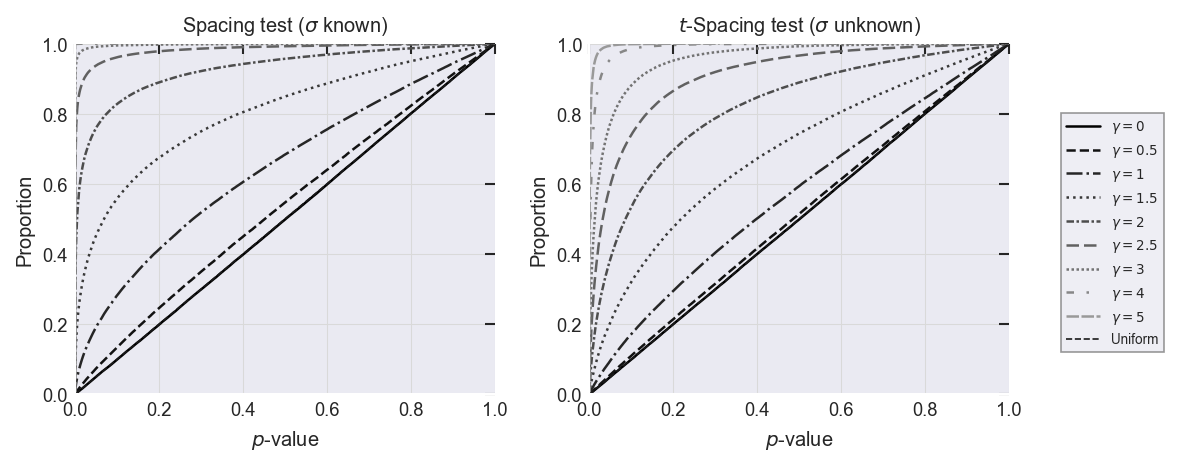

Saved to ../PNG/pvalue_cdf.pdf


In [6]:
from scipy.stats import gaussian_kde

# Grayscale-compatible style for book printing
linestyles = ["-", "--", "-.", ":", (0,(3,1,1,1)), (0,(5,2)), (0,(1,1)), (0,(3,5,1,5)), (0,(5,1))]
grays = [f"{v:.2f}" for v in np.linspace(0.0, 0.60, len(selected_gammas))]

fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))

for ax, col, title in zip(
    axes,
    ["spacing_pvalue", "tspacing_pvalue"],
    [r"Spacing test ($\sigma$ known)", r"$t$-Spacing test ($\sigma$ unknown)"],
):
    for i, gamma in enumerate(selected_gammas):
        subset = data[data["alpha"] == gamma][col].dropna().values
        ax.plot(
            np.sort(subset), np.linspace(0, 1, len(subset)),
            color=grays[i], ls=linestyles[i % len(linestyles)], lw=1.2,
            label=rf"$\gamma={gamma}$",
        )
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Uniform")
    ax.set(xlabel=r"$p$-value", ylabel="Proportion",
           xlim=(0, 1), ylim=(0, 1), title=title)
    ax.tick_params(direction="in", top=True, right=True)
    ax.set_axisbelow(True)
    ax.grid(True, color="0.85", linewidth=0.5)

# Single shared legend on the right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=6.5, frameon=True, edgecolor="gray",
           fancybox=False, ncol=1, loc="center left",
           bbox_to_anchor=(1.01, 0.5), handlelength=2.5)
sns.despine(left=False, bottom=False)
fig.tight_layout()
fig.savefig("../PNG/pvalue_cdf.pdf", bbox_inches="tight")
plt.show()
print("Saved to ../PNG/pvalue_cdf.pdf")

Under the null ($\gamma=0$), both tests are **perfectly calibrated**: the CDF closely follows the diagonal. As $\gamma$ increases, the $p$-values concentrate near $0$, confirming the tests' power against sparse alternatives.

---
## 5. Violin plots: Spacing vs. $t$-Spacing $p$-values

Split violin plots compare the distributions of the two $p$-values side by side for each $\gamma$.

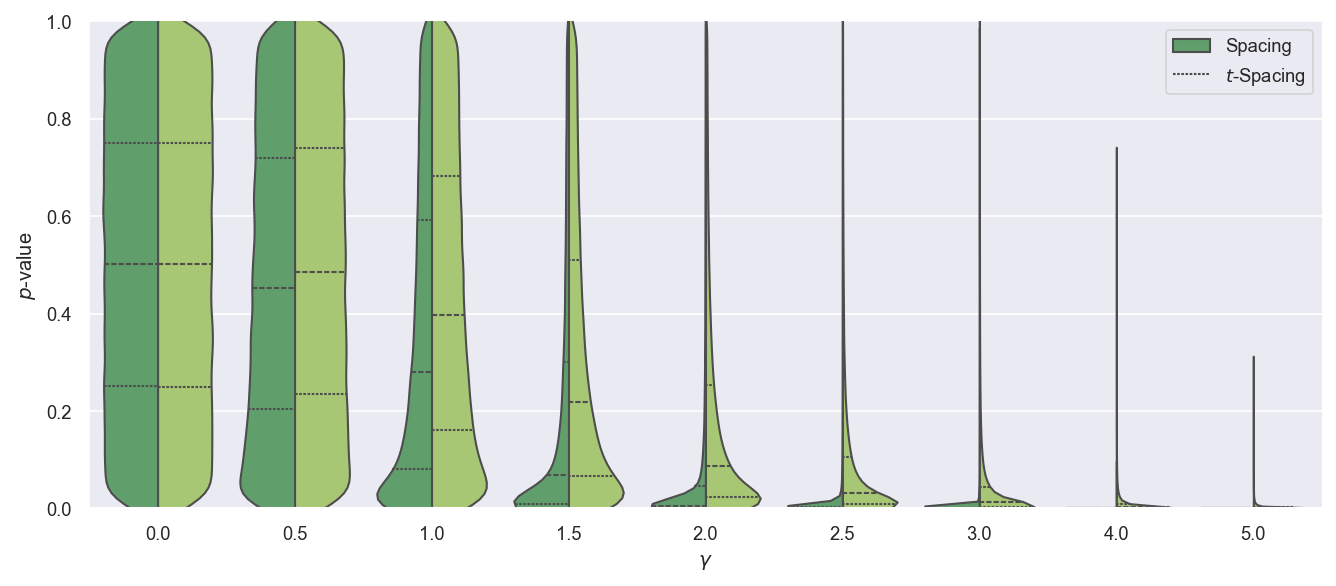

In [7]:
df_pval = data.melt(
    id_vars=["alpha"],
    value_vars=["spacing_pvalue", "tspacing_pvalue"],
    var_name="test", value_name="pvalue",
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.violinplot(
    data=df_pval, x="alpha", y="pvalue", hue="test",
    palette="summer", inner="quartile",
    density_norm="count", split=True, ax=ax,
)
ax.set(xlabel=r"$\gamma$", ylabel=r"$p$-value", ylim=(0, 1))
ax.legend(labels=["Spacing", r"$t$-Spacing"])
sns.despine()
fig.tight_layout()
plt.show()

---
## 6. Histograms of $p$-values

Under the null, the density of $p$-values should be flat (uniform). Under the alternative, mass concentrates near $0$.

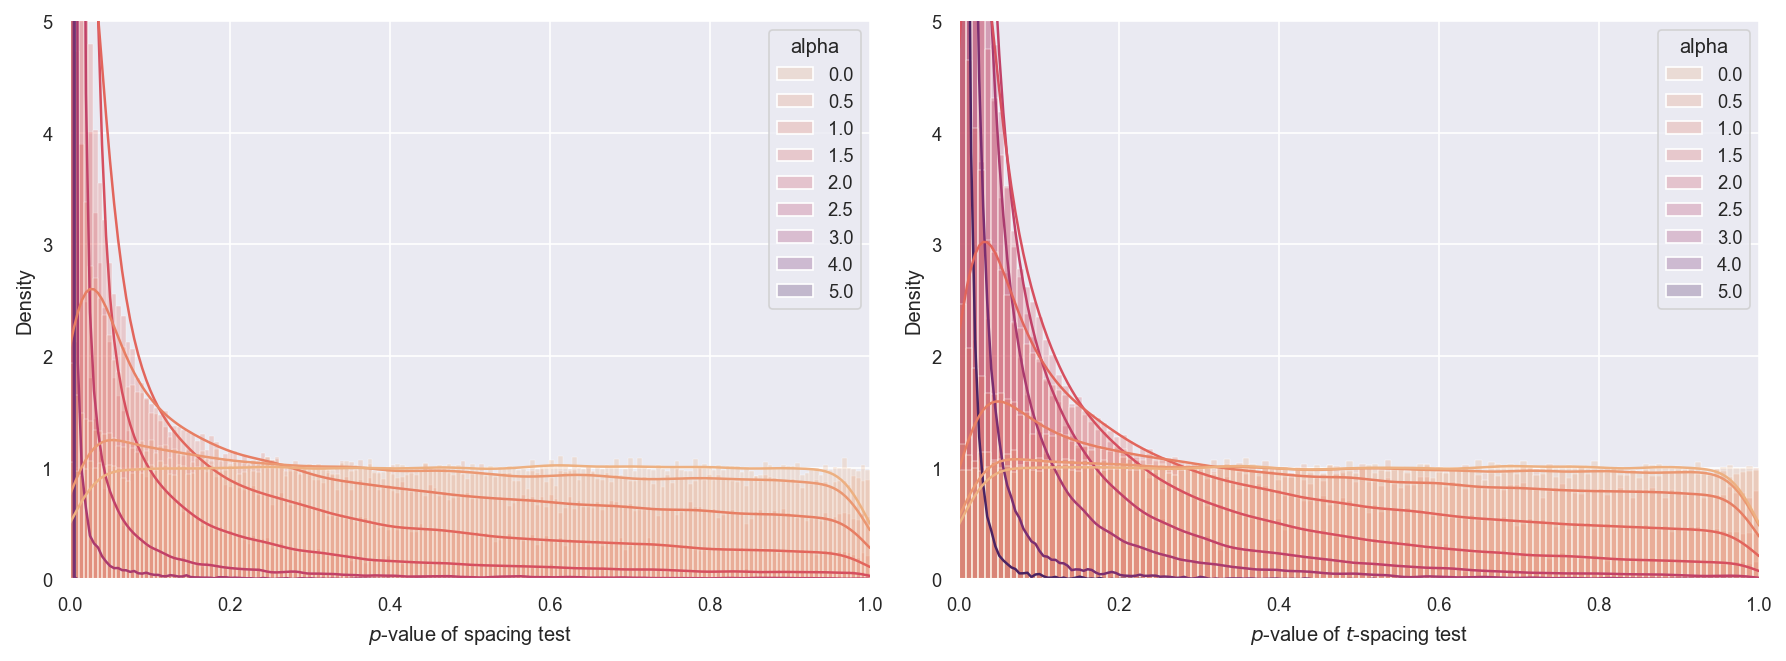

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, col, xlabel in zip(
    axes,
    ["spacing_pvalue", "tspacing_pvalue"],
    [r"$p$-value of spacing test", r"$p$-value of $t$-spacing test"],
):
    subset = df_pval[df_pval["test"] == col]
    sns.histplot(
        data=subset, x="pvalue", hue="alpha",
        stat="density", kde=True, palette="flare",
        alpha=0.25, common_norm=False, ax=ax,
    )
    ax.set(xlabel=xlabel, ylabel="Density", xlim=(0, 1), ylim=(0, 5))
    sns.despine()

fig.tight_layout()
plt.show()

---
## 7. First and second maxima $\lambda_1$, $\lambda_2$

The first maximum $\lambda_1$ is stochastically increasing with $\gamma$, while $\lambda_2$ remains approximately unchanged for moderate $\gamma$. The growing gap between them is what the spacing test detects.

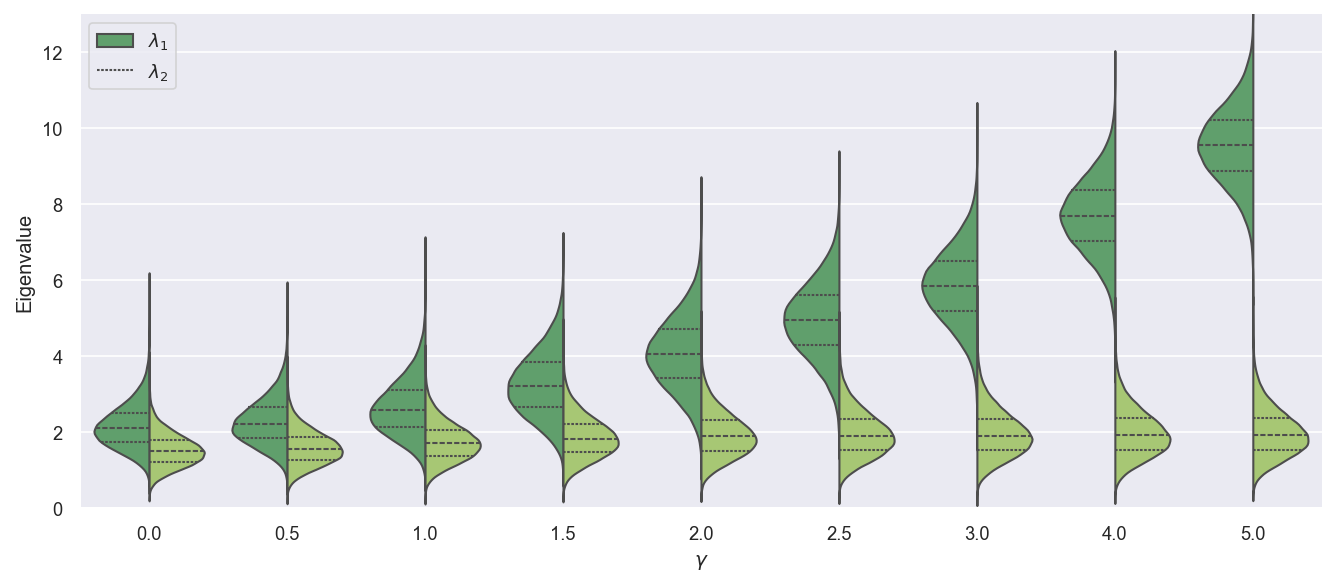

In [9]:
df_lambda = data.melt(
    id_vars=["alpha"],
    value_vars=["lambda_1", "lambda_2"],
    var_name="eigenvalue", value_name="value",
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.violinplot(
    data=df_lambda, x="alpha", y="value", hue="eigenvalue",
    palette="summer", inner="quartile",
    density_norm="count", split=True, ax=ax,
)
ax.set(xlabel=r"$\gamma$", ylabel="Eigenvalue", ylim=(0, 13))
ax.legend(labels=[r"$\lambda_1$", r"$\lambda_2$"])
sns.despine()
fig.tight_layout()
plt.show()

### Distribution of $\lambda_1$ and $\lambda_2$ (histograms)

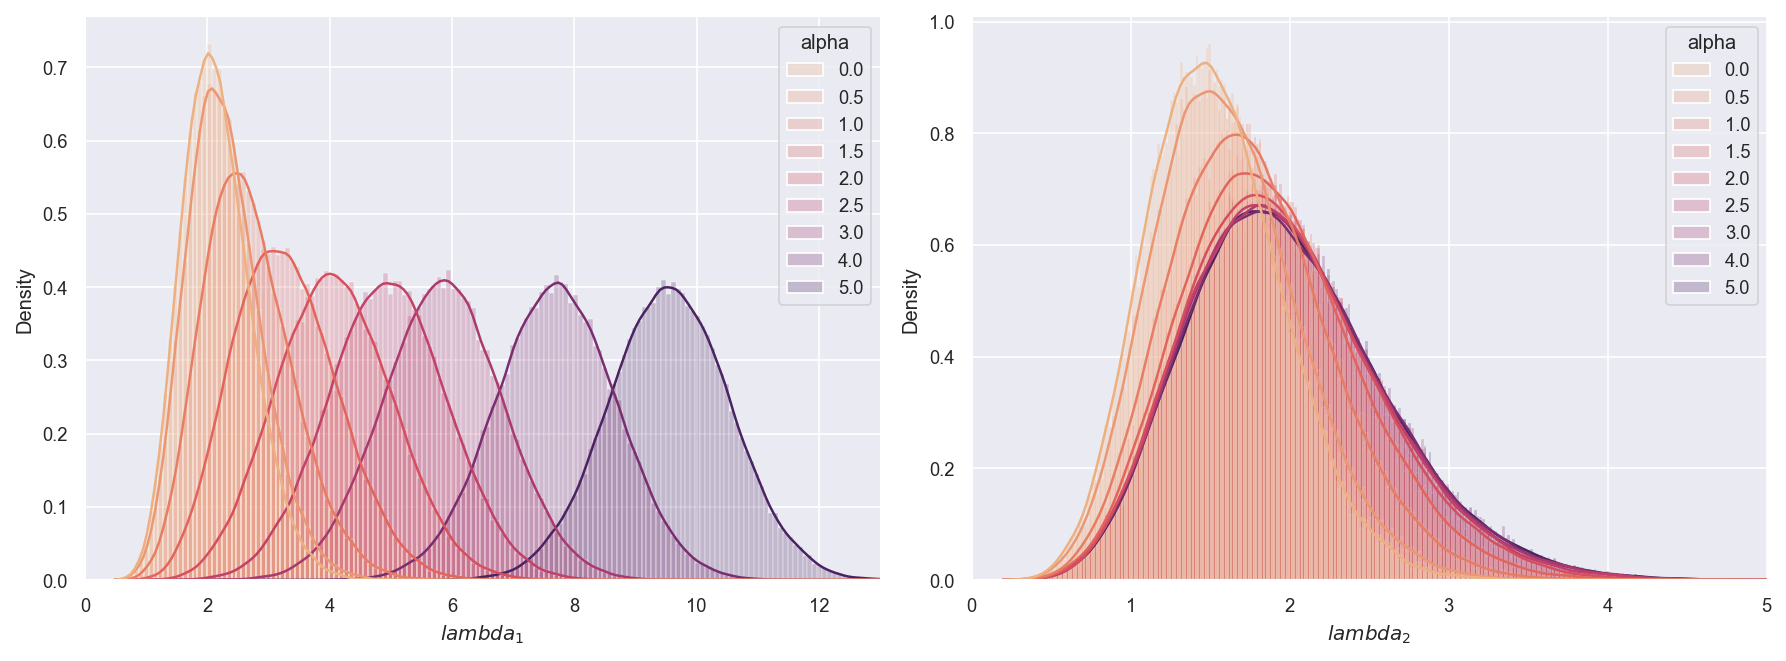

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, lbl, xlim in zip(axes, ["lambda_1", "lambda_2"], [(0, 13), (0, 5)]):
    subset = df_lambda[df_lambda["eigenvalue"] == lbl]
    sns.histplot(
        data=subset, x="value", hue="alpha",
        stat="density", kde=True, palette="flare",
        alpha=0.25, common_norm=False, ax=ax,
    )
    ax.set(xlabel=f"${lbl.replace('_', '`_')}$".replace("`", ""),
           ylabel="Density", xlim=xlim)
    sns.despine()

fig.tight_layout()
plt.show()

### Centered $\lambda_1$: distribution of $\lambda_1 - \lambda_0$

For moderate $\gamma$, the distribution of $\lambda_1 - \lambda_0$ approaches $\mathcal{N}(0,1)$ (dashed line), consistent with $\lambda_1 \approx \sigma X(t_0) + \lambda_0$ under the alternative.

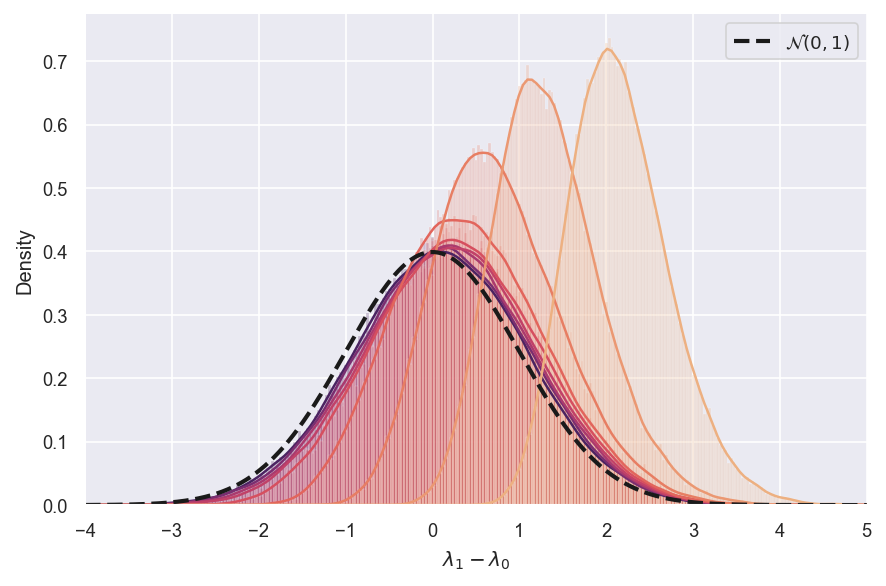

In [11]:
df_lambda1_centered = data[["alpha", "lambda_1"]].copy()
lambda_0_shift = np.sqrt(3 * np.log(3) + 3 * np.log(np.log(3)))
df_lambda1_centered["value"] = (
    df_lambda1_centered["lambda_1"] - lambda_0_shift * df_lambda1_centered["alpha"]
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(
    data=df_lambda1_centered, x="value", hue="alpha",
    stat="density", kde=True, palette="flare",
    alpha=0.25, common_norm=False, ax=ax,
)
grid = np.linspace(-4, 5, 1000)
ax.plot(grid, norm.pdf(grid), "k--", lw=2, label=r"$\mathcal{N}(0,1)$")
ax.set(xlabel=r"$\lambda_1 - \lambda_0$", ylabel="Density", xlim=(-4, 5))
ax.legend()
sns.despine()
fig.tight_layout()
plt.show()

---
## 8. Geodesic distances $d(t_0, t_1)$ and $d(t_1, t_2)$

The distance $d(t_0, t_1)$ is normalized so that it is $\mathrm{Uniform}(0,1)$ when $t_1$ is uniformly distributed on the sphere (i.e., under the null). As $\gamma$ grows, $t_1 \to t_0$ and $d(t_0, t_1)$ concentrates near $0$.

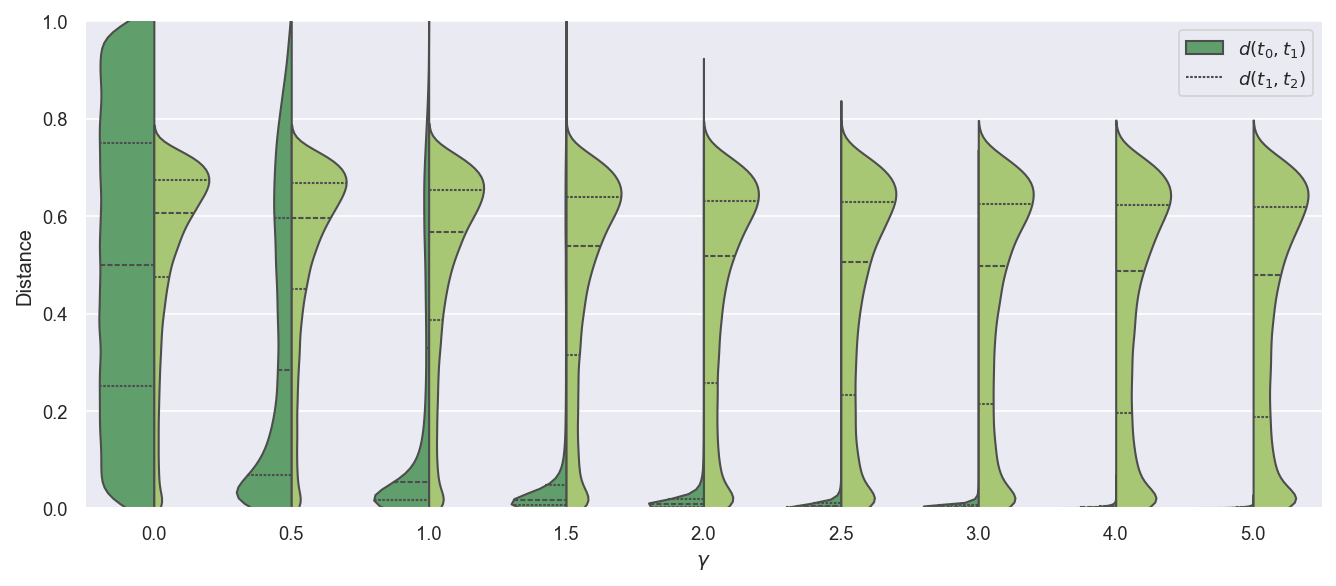

In [12]:
df_dist = data.melt(
    id_vars=["alpha"],
    value_vars=["distance_t0t1", "distance_t1t2"],
    var_name="distance", value_name="value",
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.violinplot(
    data=df_dist, x="alpha", y="value", hue="distance",
    palette="summer", inner="quartile",
    density_norm="count", split=True, ax=ax,
)
ax.set(xlabel=r"$\gamma$", ylabel="Distance", ylim=(0, 1))
ax.legend(labels=[r"$d(t_0, t_1)$", r"$d(t_1, t_2)$"])
sns.despine()
fig.tight_layout()
plt.show()

### CDF of $d(t_0, t_1)$

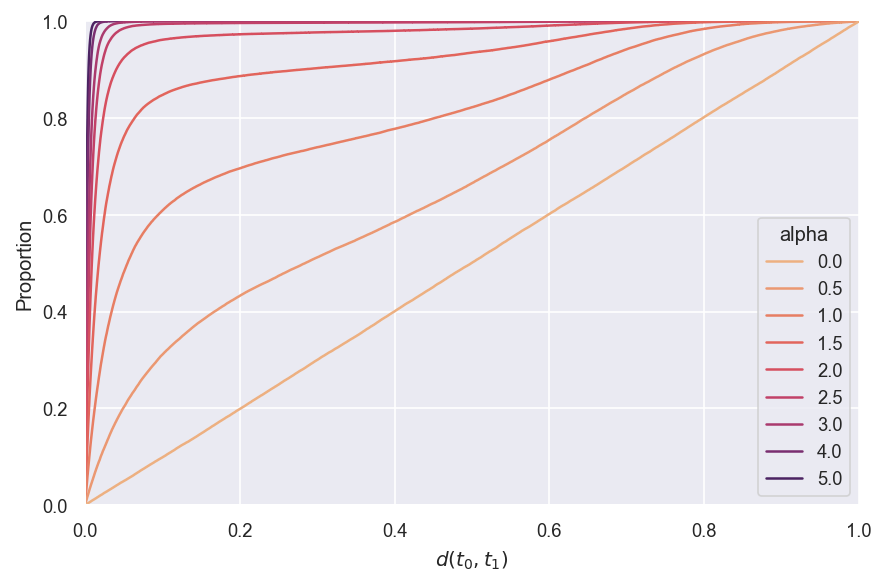

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.ecdfplot(
    data=data, x="distance_t0t1", hue="alpha",
    palette="flare", ax=ax,
)
ax.set(xlabel=r"$d(t_0, t_1)$", ylabel="Proportion",
       xlim=(0, 1), ylim=(0, 1))
sns.despine()
fig.tight_layout()
plt.show()

### Histograms of distances

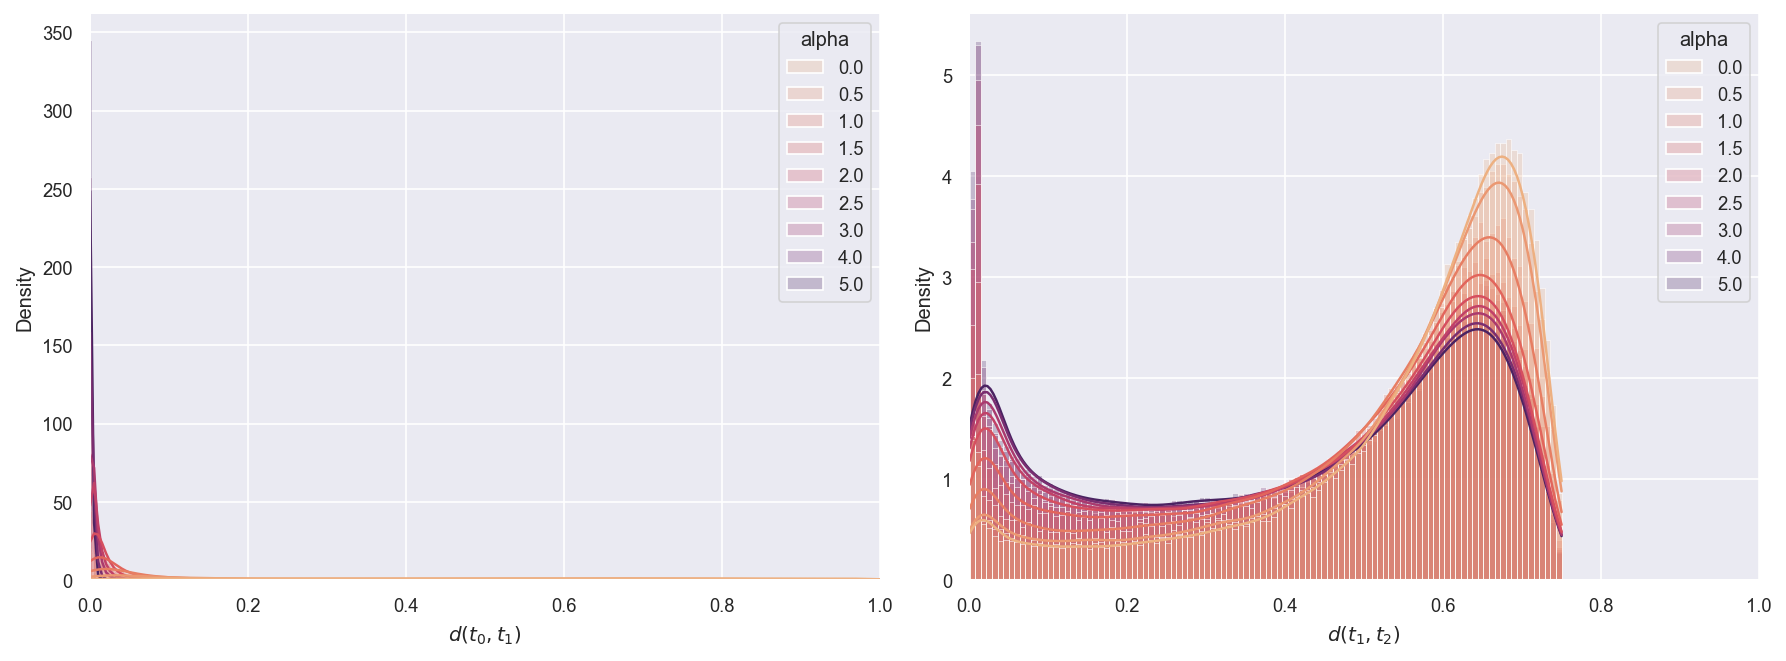

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, col, xlabel in zip(
    axes,
    ["distance_t0t1", "distance_t1t2"],
    [r"$d(t_0, t_1)$", r"$d(t_1, t_2)$"],
):
    subset = df_dist[df_dist["distance"] == col]
    sns.histplot(
        data=subset, x="value", hue="alpha",
        stat="density", kde=True, palette="flare",
        alpha=0.25, common_norm=False, ax=ax,
    )
    ax.set(xlabel=xlabel, ylabel="Density", xlim=(0, 1))
    sns.despine()

fig.tight_layout()
plt.show()

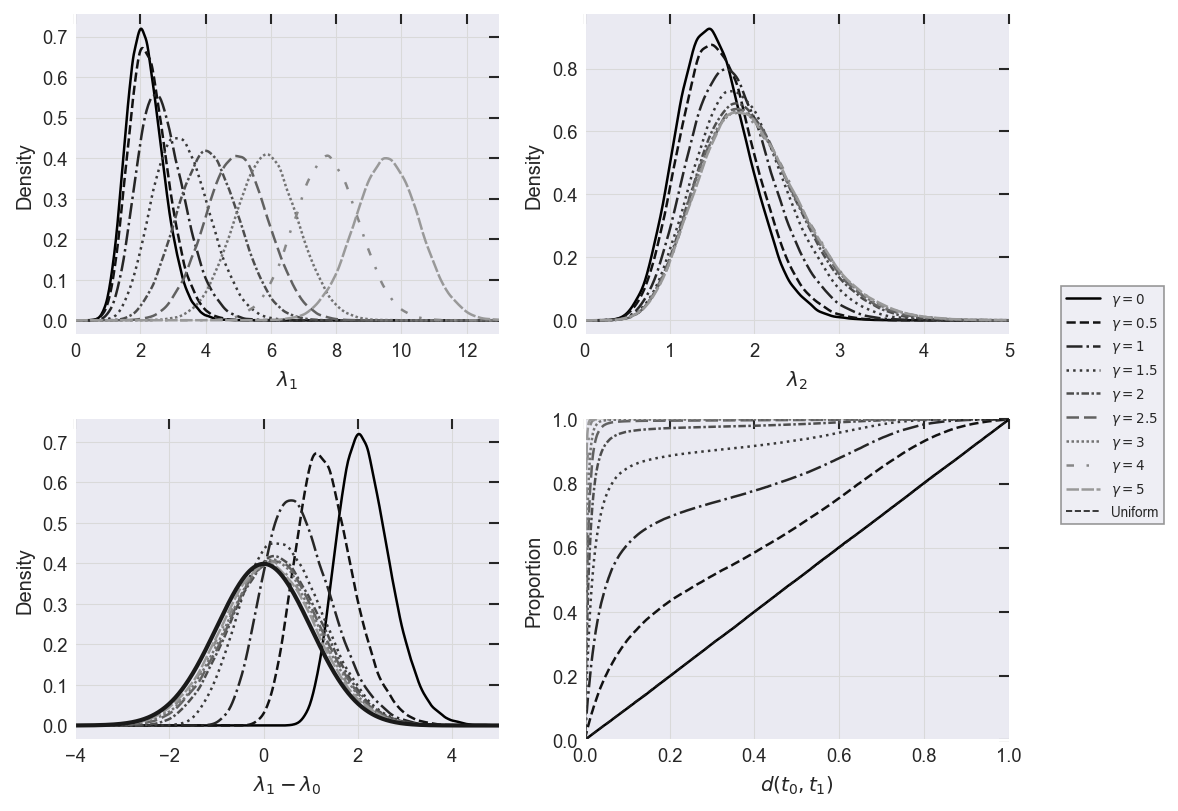

Saved to ../PNG/maxima_distance_overview.pdf


In [15]:
from scipy.stats import gaussian_kde

# Grayscale-compatible style for book printing
linestyles = ["-", "--", "-.", ":", (0,(3,1,1,1)), (0,(5,2)), (0,(1,1)), (0,(3,5,1,5)), (0,(5,1))]
grays = [f"{v:.2f}" for v in np.linspace(0.0, 0.60, len(selected_gammas))]
lambda_0_shift = np.sqrt(3 * np.log(3) + 3 * np.log(np.log(3)))

fig, axes = plt.subplots(2, 2, figsize=(7, 5.5))

# --- Top left: PDF of lambda_1 ---
ax = axes[0, 0]
for i, gamma in enumerate(selected_gammas):
    vals = data[data["alpha"] == gamma]["lambda_1"].dropna().values
    kde = gaussian_kde(vals)
    x_grid = np.linspace(0, 13, 500)
    ax.plot(x_grid, kde(x_grid), color=grays[i], ls=linestyles[i], lw=1.2,
            label=rf"$\gamma={gamma}$")
ax.set(xlabel=r"$\lambda_1$", ylabel="Density", xlim=(0, 13))

# --- Top right: PDF of lambda_2 ---
ax = axes[0, 1]
for i, gamma in enumerate(selected_gammas):
    vals = data[data["alpha"] == gamma]["lambda_2"].dropna().values
    kde = gaussian_kde(vals)
    x_grid = np.linspace(0, 5, 500)
    ax.plot(x_grid, kde(x_grid), color=grays[i], ls=linestyles[i], lw=1.2,
            label=rf"$\gamma={gamma}$")
ax.set(xlabel=r"$\lambda_2$", ylabel="Density", xlim=(0, 5))

# --- Bottom left: PDF of lambda_1 - lambda_0 ---
ax = axes[1, 0]
for i, gamma in enumerate(selected_gammas):
    vals = data[data["alpha"] == gamma]["lambda_1"].dropna().values - lambda_0_shift * gamma
    kde = gaussian_kde(vals)
    x_grid = np.linspace(-4, 5, 500)
    ax.plot(x_grid, kde(x_grid), color=grays[i], ls=linestyles[i], lw=1.2,
            label=rf"$\gamma={gamma}$")
# Theoretical N(0,1) overlay
g = np.linspace(-4, 5, 1000)
ax.plot(g, norm.pdf(g), "k-", lw=2.0, label=r"$\mathcal{N}(0,1)$")
ax.set(xlabel=r"$\lambda_1 - \lambda_0$", ylabel="Density", xlim=(-4, 5))

# --- Bottom right: CDF of d(t_0, t_1) ---
ax = axes[1, 1]
for i, gamma in enumerate(selected_gammas):
    vals = data[data["alpha"] == gamma]["distance_t0t1"].dropna().values
    ax.plot(np.sort(vals), np.linspace(0, 1, len(vals)),
            color=grays[i], ls=linestyles[i], lw=1.2,
            label=rf"$\gamma={gamma}$")
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Uniform")
ax.set(xlabel=r"$d(t_0, t_1)$", ylabel="Proportion", xlim=(0, 1), ylim=(0, 1))

# Common styling for all axes
for ax in axes.flat:
    ax.tick_params(direction="in", top=True, right=True)
    ax.set_axisbelow(True)
    ax.grid(True, color="0.85", linewidth=0.5)

# Single shared legend on the right (take handles from bottom-right which has gamma + Uniform)
handles, labels = axes[1, 1].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=6.5, frameon=True, edgecolor="gray",
           fancybox=False, ncol=1, loc="center left",
           bbox_to_anchor=(1.01, 0.5), handlelength=2.5)
sns.despine(left=False, bottom=False)
fig.tight_layout()
fig.savefig("../PNG/maxima_distance_overview.pdf", bbox_inches="tight")
plt.show()
print("Saved to ../PNG/maxima_distance_overview.pdf")

---
## 9. Estimation of $\sigma$

The variance $\sigma^2$ is estimated from the Karhunen–Loève expansion of $X^{|t_1}(\cdot)$. Under the null, the rescaled estimate $\sqrt{\bar m}\,\hat\sigma$ follows a $\chi_{\bar m}$ distribution with $\bar m = m - d - 1 = 7$ degrees of freedom (dashed line).

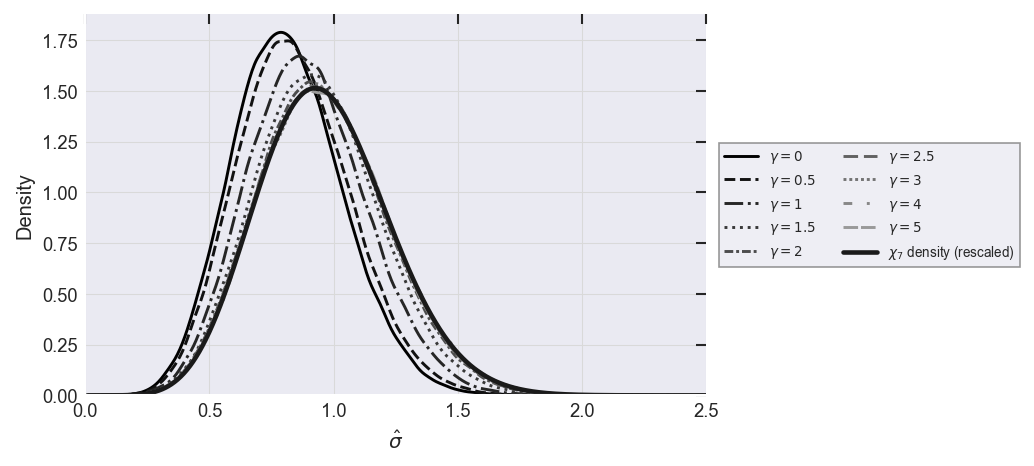

Saved to ../PNG/sigma_estimate.pdf


In [16]:
m_bar = 7  # m - d - 1 = 10 - 2 - 1
from scipy.stats import gaussian_kde

# Grayscale-compatible style for book printing
linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 2)), (0, (1, 1)), (0, (3, 5, 1, 5)), (0, (5, 1))]
grays = [f"{v:.2f}" for v in np.linspace(0.0, 0.60, len(selected_gammas))]

fig, ax = plt.subplots(figsize=(7, 3.2))

for i, gamma in enumerate(selected_gammas):
    subset = data[data["alpha"] == gamma]["sigma_estimate"]
    kde = gaussian_kde(subset.values)
    x_grid = np.linspace(0, 2.5, 500)
    ax.plot(
        x_grid, kde(x_grid),
        color=grays[i], ls=linestyles[i % len(linestyles)], lw=1.4,
        label=rf"$\gamma={gamma}$",
    )

# Theoretical density
grid = np.linspace(0.01, 2.5, 1000)
theoretical_pdf = np.sqrt(m_bar) * chi.pdf(np.sqrt(m_bar) * grid, df=m_bar)
ax.plot(grid, theoretical_pdf, "k-", lw=2.2, label=rf"$\chi_{{{m_bar}}}$ density (rescaled)")

ax.set(xlabel=r"$\hat\sigma$", ylabel="Density",
       xlim=(0, 2.5), ylim=(0, None))
ax.legend(fontsize=6.5, frameon=True, edgecolor="gray", fancybox=False, ncol=2,
          loc="center left", bbox_to_anchor=(1.01, 0.5), handlelength=2.5)
ax.tick_params(direction="in", top=True, right=True)
ax.set_axisbelow(True)
ax.grid(True, color="0.85", linewidth=0.5)
sns.despine(left=False, bottom=False)
fig.tight_layout()
fig.savefig("../PNG/sigma_estimate.pdf", bbox_inches="tight")
plt.show()
print("Saved to ../PNG/sigma_estimate.pdf")

---
## 10. Random part of the Riemannian Hessian $\Omega$

The determinant and trace of the random Hessian $\Omega$ characterize the curvature at the maximum $t_1$. Their distributions should be stable across $\gamma$ values, as $\Omega$ is independent of the signal direction.

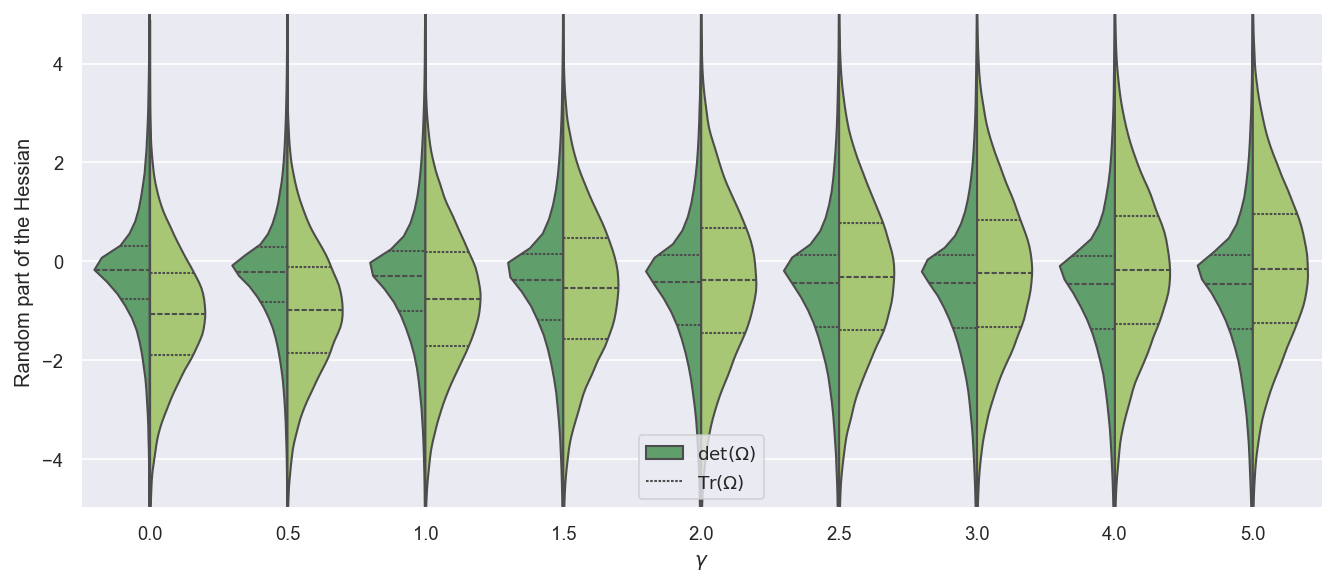

In [17]:
df_hess = data.melt(
    id_vars=["alpha"],
    value_vars=["det_R", "trace_R"],
    var_name="Hessian", value_name="value",
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.violinplot(
    data=df_hess, x="alpha", y="value", hue="Hessian",
    palette="summer", inner="quartile",
    density_norm="count", split=True, ax=ax,
)
ax.set(xlabel=r"$\gamma$", ylabel="Random part of the Hessian", ylim=(-5, 5))
ax.legend(labels=[r"$\det(\Omega)$", r"$\mathrm{Tr}(\Omega)$"])
sns.despine()
fig.tight_layout()
plt.show()

### Histograms of $\det(\Omega)$ and $\mathrm{Tr}(\Omega)$

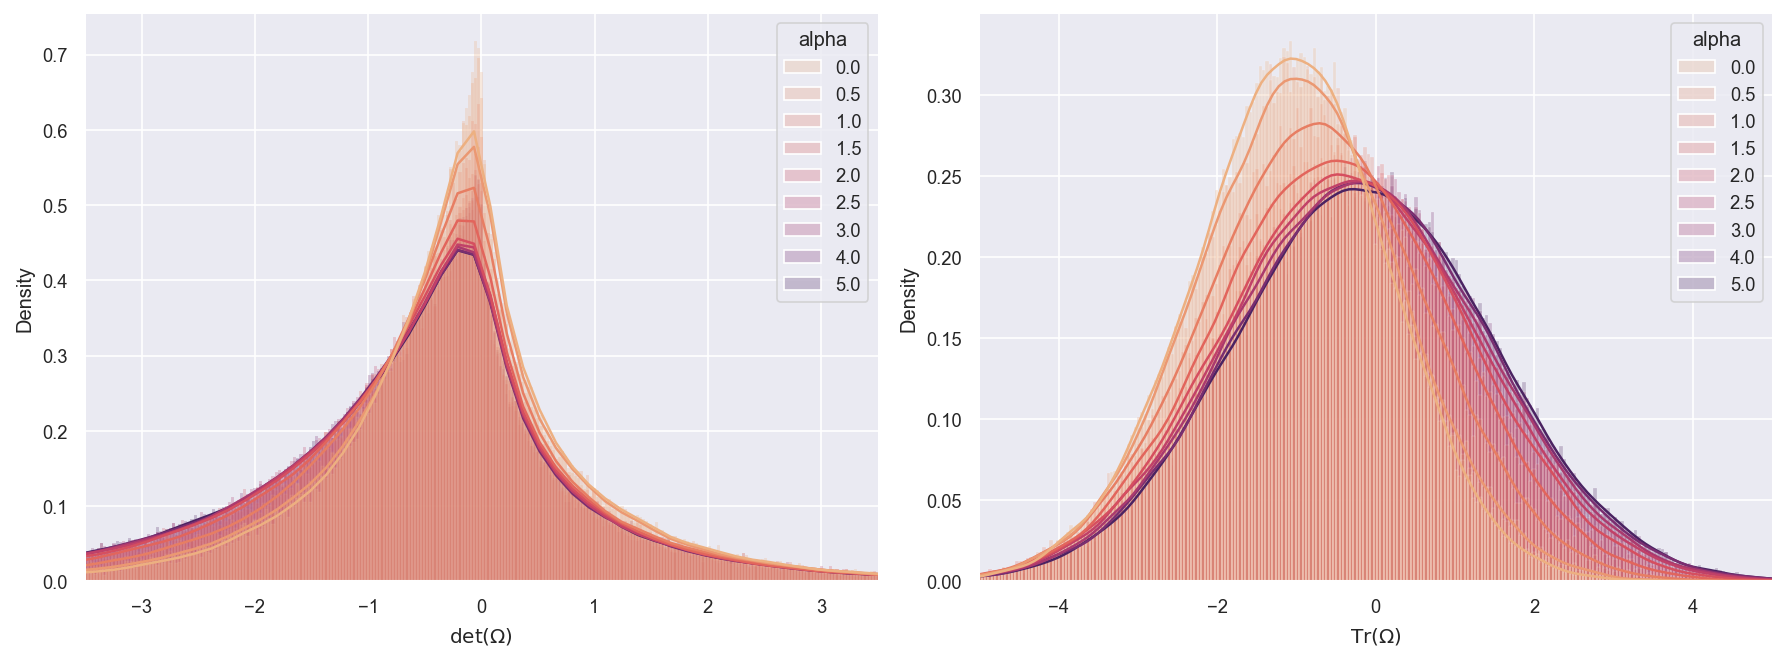

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, col, xlabel, xlim in zip(
    axes,
    ["det_R", "trace_R"],
    [r"$\det(\Omega)$", r"$\mathrm{Tr}(\Omega)$"],
    [(-3.5, 3.5), (-5, 5)],
):
    subset = df_hess[df_hess["Hessian"] == col]
    sns.histplot(
        data=subset, x="value", hue="alpha",
        stat="density", kde=True, palette="flare",
        alpha=0.25, common_norm=False, ax=ax,
    )
    ax.set(xlabel=xlabel, ylabel="Density", xlim=xlim)
    sns.despine()

fig.tight_layout()
plt.show()

---
## 11. Scatter: Spacing vs. $t$-Spacing $p$-values

A scatter plot shows the relationship between the two $p$-values. Under the null, they should be jointly close to uniform on $[0,1]^2$. Under the alternative, both concentrate near the origin.

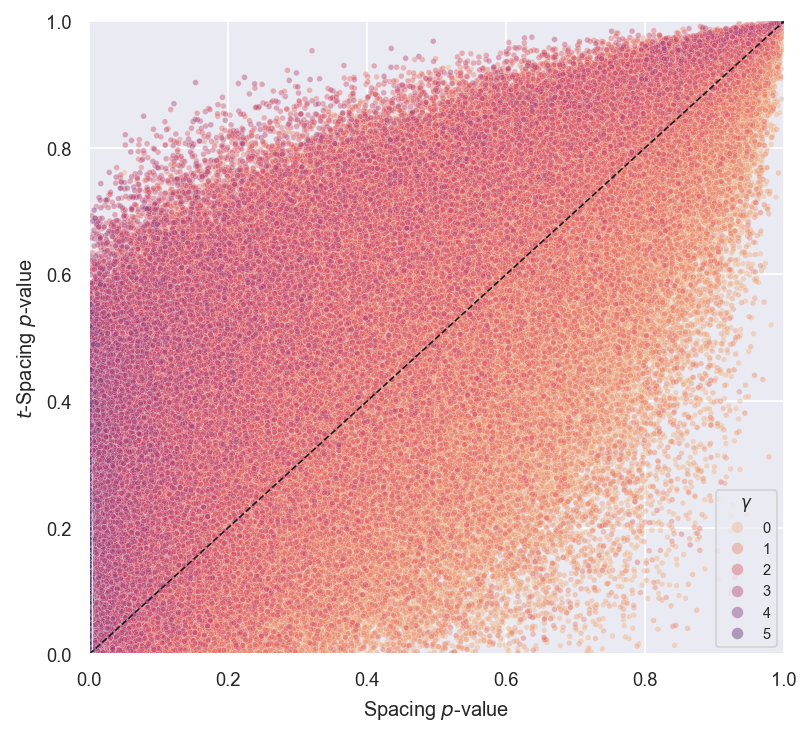

In [19]:
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.scatterplot(
    data=data, x="spacing_pvalue", y="tspacing_pvalue",
    hue="alpha", palette="flare", s=8, alpha=0.4, ax=ax,
)
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set(
    xlabel=r"Spacing $p$-value",
    ylabel=r"$t$-Spacing $p$-value",
    xlim=(0, 1), ylim=(0, 1),
)
ax.legend(title=r"$\gamma$", fontsize=7, title_fontsize=8, markerscale=2)
sns.despine()
fig.tight_layout()
plt.show()

---
## 12. Summary

The experiments confirm the theoretical results of the paper:

1. **Perfect calibration under $\mathbb{H}_0$**: Both the spacing and $t$-spacing test $p$-values are uniformly distributed when $\gamma = 0$.
2. **Power against sparse alternatives**: As the signal strength $\gamma$ increases past the phase transition ($\gamma = 1$), the $p$-values concentrate near $0$.
3. **Consistency of the MLE**: The first arg-maximum $t_1$ converges to the true signal location $t_0$ as $\gamma$ grows.
4. **$\lambda_1 \approx \mathcal{N}(\lambda_0, \sigma^2)$**: For moderate $\gamma$, the centered first maximum follows a standard normal distribution.
5. **Stability of $\lambda_2$**: The second maximum is insensitive to the signal, confirming that the spacing grows linearly with $\gamma$.
6. **Accurate $\hat\sigma$**: The variance estimator follows the predicted $\chi$ distribution.

---
## 13. 3D Visualization: Random field on $\mathbb{S}^2$

We generate a single realization of the tensor random field $X(t) = \langle W, t^{\otimes 3}\rangle_E$ under the null hypothesis ($\lambda_0 = 0$). We then display:
1. **Volumic helix** (color and grayscale): the regressed field $X^{|t_1}$ shown as a deformed sphere.
2. **First eigenvector** $t_1$: the maximum of $X$ on the sphere.
3. **First and second eigenvectors** $t_1, t_2$: the maxima of $X$ and $X^{|t_1}$.

In [ ]:
from matplotlib import cm
from matplotlib.colors import BoundaryNorm, Normalize
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.proj3d import proj_transform

# 3D arrow with proper arrowhead (rendered in 2D after projection → always visible)
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return min(zs)

def _add_arrow3d(ax, origin, direction, length=0.5, color='k', lw=2.5):
    """Add a 3D arrow from origin along direction with given length."""
    tip = origin + length * direction
    a = Arrow3D([origin[0], tip[0]], [origin[1], tip[1]], [origin[2], tip[2]],
                mutation_scale=20, lw=lw, arrowstyle='-|>', color=color)
    ax.add_artist(a)

# ---- Setup: create tensor, mesh, find eigenvectors ----
np.random.seed(seed=31415)
_gv = np.random.normal(size=10)
_W = np.zeros((3, 3, 3))
np.fill_diagonal(_W, _gv[:3])
_W[0,0,1]=_W[0,1,0]=_W[1,0,0] = _gv[3]/np.sqrt(3)
_W[0,0,2]=_W[0,2,0]=_W[2,0,0] = _gv[4]/np.sqrt(3)
_W[1,1,0]=_W[1,0,1]=_W[0,1,1] = _gv[5]/np.sqrt(3)
_W[1,1,2]=_W[1,2,1]=_W[2,1,1] = _gv[6]/np.sqrt(3)
_W[2,2,0]=_W[2,0,2]=_W[0,2,2] = _gv[7]/np.sqrt(3)
_W[2,2,1]=_W[2,1,2]=_W[1,2,2] = _gv[8]/np.sqrt(3)
_W[0,1,2]=_W[0,2,1]=_W[1,0,2]=_W[1,2,0]=_W[2,0,1]=_W[2,1,0] = _gv[9]/np.sqrt(6)

# Sphere mesh
_res = 1024
_ph = np.linspace(0, np.pi, _res)
_th = np.linspace(0, 2*np.pi, _res)
_ph, _th = np.meshgrid(_ph, _th)
_xs = np.sin(_ph)*np.cos(_th)
_ys = np.sin(_ph)*np.sin(_th)
_zs = np.cos(_ph)

def _Xeval(x, y, z):
    return (_W[0,0,0]*x**3 + _W[1,1,1]*y**3 + _W[2,2,2]*z**3
            + 6*_W[0,1,2]*x*y*z
            + 3*(_W[0,0,1]*x**2*y + _W[0,0,2]*x**2*z
                 + _W[1,1,0]*y**2*x + _W[1,1,2]*y**2*z
                 + _W[2,2,0]*z**2*x + _W[2,2,1]*z**2*y))
_v = _Xeval(_xs, _ys, _zs)

def _Xpt(t):
    return _Xeval(t[0], t[1], t[2])

def _gX(t):
    g = np.zeros(3)
    g[0] = (6*(_W[0,1,2]*t[1]*t[2]+_W[0,0,2]*t[0]*t[2]+_W[0,0,1]*t[0]*t[1])
            + 3*(_W[0,0,0]*t[0]**2+_W[0,1,1]*t[1]**2+_W[0,2,2]*t[2]**2))
    g[1] = (6*(_W[1,1,2]*t[1]*t[2]+_W[1,0,2]*t[0]*t[2]+_W[1,0,1]*t[0]*t[1])
            + 3*(_W[1,0,0]*t[0]**2+_W[1,1,1]*t[1]**2+_W[1,2,2]*t[2]**2))
    g[2] = (6*(_W[2,1,2]*t[1]*t[2]+_W[2,0,2]*t[0]*t[2]+_W[2,0,1]*t[0]*t[1])
            + 3*(_W[2,0,0]*t[0]**2+_W[2,1,1]*t[1]**2+_W[2,2,2]*t[2]**2))
    return g

# First eigenvector
_i1 = np.unravel_index(np.argmax(_v), _v.shape)
_t1 = np.array([np.sin(_ph[_i1])*np.cos(_th[_i1]),
                np.sin(_ph[_i1])*np.sin(_th[_i1]),
                np.cos(_ph[_i1])])
for _ in range(10_000):
    P = np.outer(_t1, _t1)
    _t1 += 0.01 * (np.eye(3) - P) @ _gX(_t1)
    _t1 /= np.linalg.norm(_t1)
_l1 = _Xpt(_t1)

# Regressed random field
_c = (_t1[0]*_xs + _t1[1]*_ys + _t1[2]*_zs)**3
_v2 = (_v - _c * _l1) / (1 - _c)

def _X2pt(t):
    c = np.dot(_t1, t)**3
    return (_Xpt(t) - c * _l1) / (1 - c)

def _gX2(t, eps=1e-7):
    g = np.zeros(3)
    for i in range(3):
        tp = t.copy(); tp[i] += eps
        tm = t.copy(); tm[i] -= eps
        g[i] = (_X2pt(tp) - _X2pt(tm)) / (2*eps)
    return g

# Second eigenvector
_i2 = np.unravel_index(np.argmax(_v2), _v2.shape)
_t2 = np.array([np.sin(_ph[_i2])*np.cos(_th[_i2]),
                np.sin(_ph[_i2])*np.sin(_th[_i2]),
                np.cos(_ph[_i2])])
for _ in range(10_000):
    P = np.outer(_t2, _t2)
    _t2 += 0.01 * (np.eye(3) - P) @ _gX2(_t2)
    _t2 /= np.linalg.norm(_t2)
_l2 = _X2pt(_t2)

# Stepped grayscale colormap with N discrete levels
def _stepped_gray(v, n_levels=100):
    """Quantize to n discrete gray levels for visible level sets."""
    v_n = (v - v.min()) / (v.max() - v.min())
    v_q = np.floor(v_n * n_levels).clip(0, n_levels - 1) / (n_levels - 1)
    return cm.gray(v_q)

# Color mapping for color helix
def _cval(v):
    vp = np.where(v > 0, v, 0) / np.max(v)
    vn = np.where(v < 0, v, 0) / (-np.min(v))
    return vn + vp

_fc2_color = _cval(_v2)

_elev_t1 = 90 - 180*_ph[_i1]/np.pi
_azim_t1 = 360*_th[_i1]/(2*np.pi)
_sc = 1 + 0.33*_v2/_l2
RR = 0.78

# Common view for sphere figures: midpoint of t1 and t2
_mid = _t1 + _t2
_mid /= np.linalg.norm(_mid)
_elev_mid = np.degrees(np.arcsin(np.clip(_mid[2], -1, 1)))
_azim_mid = np.degrees(np.arctan2(_mid[1], _mid[0]))

print(f"λ₁ = {_l1:.4f}  at t₁ = {_t1}")
print(f"λ₂ = {_l2:.4f}  at t₂ = {_t2}")

# ---- Figure 1: Volumic helix (color) ----
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(_sc*_xs, _sc*_ys, _sc*_zs, rstride=1, cstride=1,
                facecolors=cm.Spectral_r(_fc2_color))
ax.set_xlim3d(-RR, RR); ax.set_ylim3d(-RR, RR); ax.set_zlim3d(-RR, RR)
ax.set_aspect("equal")
ax.view_init(_elev_t1 + 5, _azim_t1 + 40)
ax.set_facecolor("white"); plt.axis('off')
fig.savefig("../PNG/helix_color.png", bbox_inches='tight', transparent=True, pad_inches=0, dpi=300)
plt.show()

# ---- Figure 2: Volumic helix (grayscale, stepped) ----
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(_sc*_xs, _sc*_ys, _sc*_zs, rstride=1, cstride=1,
                facecolors=_stepped_gray(_v2, n_levels=20), shade=False)
ax.set_xlim3d(-RR, RR); ax.set_ylim3d(-RR, RR); ax.set_zlim3d(-RR, RR)
ax.set_aspect("equal")
ax.view_init(_elev_t1 + 5, _azim_t1 + 40)
ax.set_facecolor("white"); plt.axis('off')
fig.savefig("../PNG/helix_grayscale.png", bbox_inches='tight', transparent=True, pad_inches=0, dpi=300)
plt.show()

# ---- Figure 3: Sphere + t₁ (arrow) ----
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(_xs, _ys, _zs, rstride=1, cstride=1,
                facecolors=_stepped_gray(_v, n_levels=20), shade=False)
_add_arrow3d(ax, _t1, _t1, length=0.5, color='k', lw=2.5)
ax.set_xlim([-0.9,0.9]); ax.set_ylim([-0.9,0.9]); ax.set_zlim([-0.9,0.9])
ax.set_aspect("equal")
ax.view_init(_elev_mid, _azim_mid)
ax.set_facecolor("white"); plt.axis('off')
fig.savefig("../PNG/sphere_eigenvector1.png", bbox_inches='tight', transparent=True, pad_inches=0, dpi=300)
plt.show()

# ---- Figure 4: Sphere + t₁ + t₂ (arrows) ----
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(_xs, _ys, _zs, rstride=1, cstride=1,
                facecolors=_stepped_gray(_v2, n_levels=20), shade=False)
_add_arrow3d(ax, _t1, _t1, length=0.5, color='k', lw=2.5)
_add_arrow3d(ax, _t2, _t2, length=0.5, color='0.45', lw=2.5)
ax.set_xlim([-0.9,0.9]); ax.set_ylim([-0.9,0.9]); ax.set_zlim([-0.9,0.9])
ax.set_aspect("equal")
ax.view_init(_elev_mid, _azim_mid)
ax.set_facecolor("white"); plt.axis('off')
fig.savefig("../PNG/sphere_eigenvectors12.png", bbox_inches='tight', transparent=True, pad_inches=0, dpi=300)
plt.show()

print("Saved: helix_color.png, helix_grayscale.png, sphere_eigenvector1.png, sphere_eigenvectors12.png")

λ₁ = 2.5241  at t₁ = [ 0.1623626  -0.11166524  0.9803924 ]
λ₂ = 1.9541  at t₂ = [ 0.57177533  0.80556356 -0.15537158]
